In [5]:
import pandas as pd

print("⏳ Cargando dataset real local...")
df_real = pd.read_csv("creditcard.csv")

print("✅ DATASET REAL CARGADO CON ÉXITO")
print(f"Dimensiones reales: {df_real.shape[0]:,} filas x {df_real.shape[1]} columnas")
print("\nDistribución de Clases (0 = Legítima, 1 = Fraude):")
print(df_real['Class'].value_counts())

df_real.head()

⏳ Cargando dataset real local...
✅ DATASET REAL CARGADO CON ÉXITO
Dimensiones reales: 284,807 filas x 31 columnas

Distribución de Clases (0 = Legítima, 1 = Fraude):
Class
0    284315
1       492
Name: count, dtype: int64


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, average_precision_score

# 1. Separar variables de entrada (X) y el objetivo (y)
X = df_real.drop(columns=['Class'])
y = df_real['Class']

# 2. División Stratified (Mantiene la proporción exacta del 0.17% de fraudes tanto en train como en test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("⚙️ Entrenando modelo sobre 227,845 transacciones de entrenamiento...")

# 3. Entrenar Random Forest optimizado
modelo_antifraude_real = RandomForestClassifier(
    n_estimators=100, 
    max_depth=10, 
    class_weight='balanced', 
    random_state=42, 
    n_jobs=-1
)
modelo_antifraude_real.fit(X_train, y_train)

# 4. Generar predicciones sobre los datos de prueba (56,962 transacciones que nunca vio)
y_pred = modelo_antifraude_real.predict(X_test)
y_prob = modelo_antifraude_real.predict_proba(X_test)[:, 1]

# 5. Métricas para la banca
auprc = average_precision_score(y_test, y_prob)

print("\n==================================================")
print(f"🛡️ EVALUACIÓN FINANCIERA REAL (AUPRC Score: {auprc:.4f})")
print("==================================================")
print(classification_report(y_test, y_pred, target_names=['Legítima (0)', 'Fraude (1)']))

⚙️ Entrenando modelo sobre 227,845 transacciones de entrenamiento...

🛡️ EVALUACIÓN FINANCIERA REAL (AUPRC Score: 0.8177)
              precision    recall  f1-score   support

Legítima (0)       1.00      1.00      1.00     56864
  Fraude (1)       0.82      0.83      0.82        98

    accuracy                           1.00     56962
   macro avg       0.91      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962



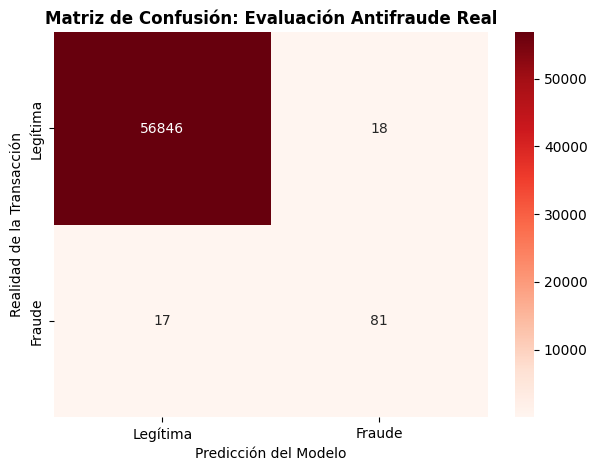

✅ Fraudes Atajados con Éxito: 81 de 98
🚨 Fraudes que se Escaparon: 17
⚠️ Alertas Falsas (Bloqueos molestos a clientes reales): 18


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=['Legítima', 'Fraude'], yticklabels=['Legítima', 'Fraude'])
plt.title('Matriz de Confusión: Evaluación Antifraude Real', fontsize=12, fontweight='bold')
plt.xlabel('Predicción del Modelo', fontsize=10)
plt.ylabel('Realidad de la Transacción', fontsize=10)
plt.show()

# Cálculos de negocio
verdaderos_positivos = cm[1,1] # Fraudes atajados
falsos_negativos = cm[1,0]     # Fraudes que se escaparon
falsos_positivos = cm[0,1]     # Clientes legítimos bloqueados por error

print(f"✅ Fraudes Atajados con Éxito: {verdaderos_positivos} de {verdaderos_positivos + falsos_negativos}")
print(f"🚨 Fraudes que se Escaparon: {falsos_negativos}")
print(f"⚠️ Alertas Falsas (Bloqueos molestos a clientes reales): {falsos_positivos}")

In [8]:
import numpy as np
from sklearn.metrics import confusion_matrix

# 1. Probar un umbral de decisión más agresivo (ej: 15% de probabilidad)
nuevo_umbral = 0.15
y_pred_agresivo = (y_prob >= nuevo_umbral).astype(int)

# 2. Calcular la nueva matriz de confusión
cm_agresivo = confusion_matrix(y_test, y_pred_agresivo)

verdaderos_positivos_nuevo = cm_agresivo[1, 1]
falsos_negativos_nuevo = cm_agresivo[1, 0]
falsos_positivos_nuevo = cm_agresivo[0, 1]

print("==================================================")
print(f"🎯 SISTEMA ANTIFRAUDE AGRESIVO (Umbral: {nuevo_umbral * 100}%)")
print("==================================================")
print(f"✅ Fraudes Atajados con Éxito: {verdaderos_positivos_nuevo} de {verdaderos_positivos_nuevo + falsos_negativos_nuevo}")
print(f"🚨 Fraudes que se Escaparon: {falsos_negativos_nuevo}")
print(f"⚠️ Alertas Falsas (Bloqueos a revisar): {falsos_positivos_nuevo}")

🎯 SISTEMA ANTIFRAUDE AGRESIVO (Umbral: 15.0%)
✅ Fraudes Atajados con Éxito: 88 de 98
🚨 Fraudes que se Escaparon: 10
⚠️ Alertas Falsas (Bloqueos a revisar): 268


In [9]:
# Umbral ultra-sensible (5%) para priorizar la tasa de captura de fraudes
umbral_ultra = 0.05
y_pred_ultra = (y_prob >= umbral_ultra).astype(int)

cm_ultra = confusion_matrix(y_test, y_pred_ultra)

vp_u = cm_ultra[1, 1]
fn_u = cm_ultra[1, 0]
fp_u = cm_ultra[0, 1]

print("==================================================")
print(f"🛡️ SISTEMA BLINDAJE BANCO (Umbral de Alerta: {umbral_ultra * 100}%)")
print("==================================================")
print(f"✅ Fraudes Atajados: {vp_u} de {vp_u + fn_u} ({vp_u/(vp_u+fn_u)*100:.1f}%)")
print(f"🚨 Fraudes Escapados: {fn_u}")
print(f"⚠️ Operaciones enviadas a Verificación 2FA / SMS: {fp_u}")

🛡️ SISTEMA BLINDAJE BANCO (Umbral de Alerta: 5.0%)
✅ Fraudes Atajados: 89 de 98 (90.8%)
🚨 Fraudes Escapados: 9
⚠️ Operaciones enviadas a Verificación 2FA / SMS: 2132
